## Neural Network from Scratch: MNIST Digit Classifier

**Introduction**

Most people learning machine learning jump straight into TensorFlow or PyTorch without understanding what is actually happening under the hood.
In this project I built a fully functioning neural network using only NumPy to deeply understand the mathematics that power modern AI. Every single component was written by hand:

- Forward propagation
- Activation functions (ReLU and Softmax)
- Cross entropy loss
- Backpropagation and the chain rule
- Gradient descent and weight updates

The dataset used is MNIST, the "hello world" of machine learning, containing 70,000 handwritten digit images. The final model achieves 90%+ accuracy on unseen test data.
This is purely self study and preparation for bigger projects. No shortcuts taken.

## Libraries

This project intentionally avoids deep learning frameworks such as TensorFlow or PyTorch. The goal is to implement the neural network mechanics manually using NumPy.

The project uses:

- **NumPy**: matrix operations, numerical computation, and data manipulation
- **Matplotlib**: visualizing images, predictions, and training curves
- **urllib.request**: downloading the raw MNIST dataset
- **gzip**: decompressing the dataset files
- **pathlib**: managing file paths in a clean and readable way

In [43]:
#import libraries
from pathlib import Path
import gzip
import urllib.request
import matplotlib.pyplot as plt
import numpy as np

In [44]:
DATA_DIR = Path("../data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

## Downloading the Dataset

The raw MNIST files are downloaded directly from the official dataset mirror and stored locally inside the project directory.

In [45]:
BASE_URL = "https://ossci-datasets.s3.amazonaws.com/mnist/"

MNIST_FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz",
}

In [46]:
for filename in MNIST_FILES.values():
    file_path = DATA_DIR / filename
    if file_path.exists():
        print(f"Already downloaded: {filename}")
    else:
        print(f"Downloading: {filename}")
        urllib.request.urlretrieve(BASE_URL + filename, file_path)
        print(f"Saved to: {file_path}")

Already downloaded: train-images-idx3-ubyte.gz
Already downloaded: train-labels-idx1-ubyte.gz
Already downloaded: t10k-images-idx3-ubyte.gz
Already downloaded: t10k-labels-idx1-ubyte.gz


In [47]:
def parse_images(path):
    """
    Parse an MNIST image file from gzip format.

    Each image is 28x28 pixels, flattened into a vector of length 784.
    The first 16 bytes contain metadata and are skipped.
    """
    with gzip.open(path, "rb") as file:
        file.read(16)
        data = np.frombuffer(file.read(), dtype=np.uint8) #converting to 1D NumPy array
    return data.reshape(-1, 28 * 28) #-1 decides automatically the num of rows

In [48]:
def parse_labels(path):
    """
    Parse an MNIST label file from gzip format.

    The first 8 bytes contain metadata and are skipped.
    Each remaining byte represents the correct digit label for one image.
    """
    with gzip.open(path, "rb") as file:
        file.read(8)
        labels = np.frombuffer(file.read(), dtype=np.uint8)
    return labels

In [49]:
#load the training and test datasets
X_train = parse_images(DATA_DIR / MNIST_FILES["train_images"])
y_train = parse_labels(DATA_DIR / MNIST_FILES["train_labels"])

X_test = parse_images(DATA_DIR / MNIST_FILES["test_images"])
y_test = parse_labels(DATA_DIR / MNIST_FILES["test_labels"])

## Inspecting the Dataset

Each MNIST image is flattened into a vector of 784 values (28×28 pixels).  
The training set contains 60,000 images and the test set contains 10,000 images.

In [50]:
#verifying each variable
print(f"Training images shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")

print(f"Test images shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Training images shape: (60000, 784)
Training labels shape: (60000,)
Test images shape: (10000, 784)
Test labels shape: (10000,)


## Visualizing a Sample Image

Before training the model, I visualized one example from the training set to confirm that the image data and label were loaded correctly.

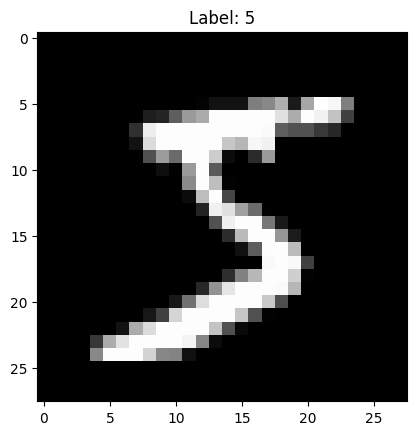

In [51]:
#display the first training image and its label
plt.imshow(X_train[0].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.show()

## Visualizing Multiple Training Examples

Viewing multiple examples helps confirm that the dataset contains a wide variety of handwritten digit styles.

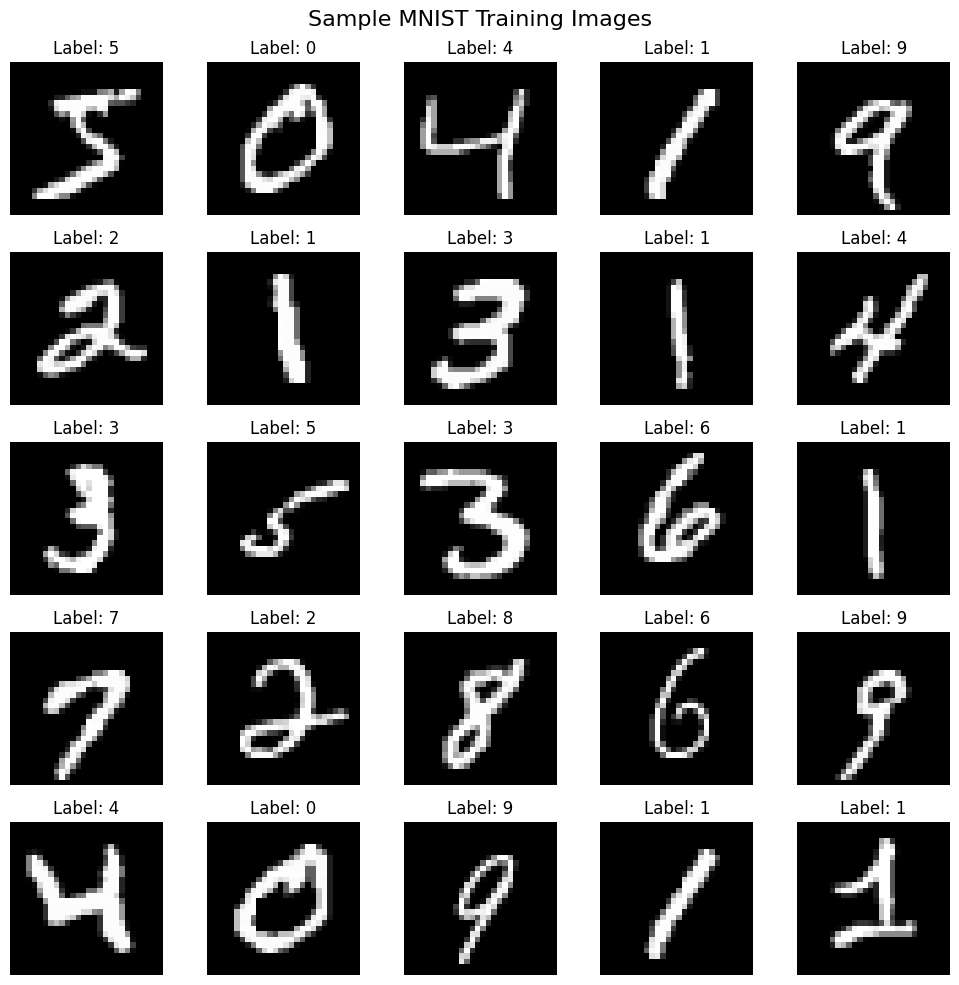

In [52]:
#display the first 25 training images
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.suptitle("Sample MNIST Training Images", fontsize=16)
plt.tight_layout()
plt.show()

## Normalizing Pixel Values

The raw pixel values range from 0 to 255.  
Dividing by 255 scales every pixel into the range [0, 1], which helps gradient descent train more smoothly.

In [53]:
#normalize pixel values from [0, 255] to [0, 1]
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print(f"Training data range: {X_train.min()} to {X_train.max()}")
print(f"Test data range: {X_test.min()} to {X_test.max()}")

Training data range: 0.0 to 1.0
Test data range: 0.0 to 1.0


## Building the Neural Network

The model is a simple fully connected neural network with one hidden layer:

- Input layer: 784 neurons, one for each pixel in a 28×28 image
- Hidden layer: 128 neurons with ReLU activation
- Output layer: 10 neurons, one for each digit class from 0 to 9

In [54]:
#set random seed for reproducibility
np.random.seed(42)

#network architecture
input_size = 28 * 28
hidden_size = 128
output_size = 10

#initialize network parameters
W1 = np.random.randn(input_size, hidden_size) * 0.01 #input -> hl (784 inputs and 128 neuron)
b1 = np.zeros(hidden_size) #one bias per neuron in the hidden layer
W2 = np.random.randn(hidden_size, output_size) * 0.01 #hl -> output (128 neurons and 10 outputs)
b2 = np.zeros(output_size) #one bias per output neuron

## Activation Functions

This neural network uses two activation functions:

### ReLU (Rectified Linear Unit)
Used in the hidden layer.

ReLU outputs:
- the input itself if the value is positive,
- zero if the value is negative.

This introduces nonlinearity into the network, allowing it to learn more complex patterns.

### Softmax
Used in the output layer.

Softmax converts raw output scores into probabilities that sum to 1, allowing the network to estimate the probability of each digit class.

In [55]:
def relu(x):
    """
    ReLU activation function.
    """
    return np.maximum(0, x)

In [56]:
def softmax(x):
    """
    Softmax activation function.

    Converts raw scores into probability distributions.
    """
    shifted_x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(shifted_x)

    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

## Forward Propagation

During forward propagation, the input data moves through the network layer by layer:

1. The hidden layer computes a weighted sum of the inputs.
2. ReLU introduces nonlinearity.
3. The output layer computes class scores.
4. Softmax converts those scores into probabilities.

In [57]:
def forward_pass(X, W1, W2, b1, b2):
    """
    Perform forward propagation through the network.
    """

    #hidden layer
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    #output layer
    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

In [58]:
#test the forward pass
Z1, A1, Z2, A2 = forward_pass(X_train, W1, W2, b1, b2)
print(f"Output shape: {A2.shape}")
print("\nFirst prediction probability distribution:")
print(A2[0])
print(f"\nSum of probabilities: {A2[0].sum():.4f}")

Output shape: (60000, 10)

First prediction probability distribution:
[0.100705   0.09999271 0.10007215 0.09885231 0.09954597 0.10055876
 0.09919235 0.10074358 0.09972406 0.1006131 ]

Sum of probabilities: 1.0000


## Cross-Entropy Loss

The model is trained using cross-entropy loss, which measures how well the predicted probability distribution matches the true labels.

Lower loss values indicate better predictions.

In [59]:
def cross_entropy_loss(A2, y):
    """
    Compute the cross-entropy loss.
    """

    num_samples = y.shape[0]

    #prevent log(0)
    epsilon = 1e-12
    clipped_A2 = np.clip(A2, epsilon, 1.0) #(a, a-min, a-max)

    correct_class_probs = clipped_A2[np.arange(num_samples), y]

    loss = -np.mean(np.log(correct_class_probs))

    return loss

In [60]:
#compute the initial loss before training
loss = cross_entropy_loss(A2, y_train)
print(f"Initial loss before training: {loss:.4f}")

Initial loss before training: 2.3031


## Backpropagation

Backpropagation computes the gradients of the loss function with respect to every parameter in the network.

Using the chain rule, the error is propagated backward through the network so the weights and biases can be updated using gradient descent.

In [61]:
def backward_pass(X, y, W2, Z1, A1, A2):
    """
    Perform backpropagation and compute gradients.
    """

    num_samples = y.shape[0]

    #one-hot encode labels
    Y_onehot = np.zeros((num_samples, output_size))
    Y_onehot[np.arange(num_samples), y] = 1

    #output layer gradients
    dZ2 = A2 - Y_onehot
    dW2 = (A1.T @ dZ2) / num_samples
    db2 = np.mean(dZ2, axis=0)

    #hidden layer gradients
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (Z1 > 0)  #ReLU derivative

    dW1 = (X.T @ dZ1) / num_samples
    db1 = np.mean(dZ1, axis=0)

    return dW1, db1, dW2, db2

### Why Softmax and Cross-Entropy Work So Well Together

When softmax activation and cross-entropy loss are combined, an elegant mathematical simplification occurs during differentiation.

The derivative of the logarithm from the cross-entropy loss interacts with the derivative of the softmax function in such a way that many terms cancel out through the chain rule.

The result is the remarkably simple expression:

[
dZ2 = A2 - Y_onehot
]

which is simply:

- the predicted probabilities
- minus the true labels

This simplification is one of the reasons why softmax and cross-entropy are almost always paired together in classification problems.


## Gradient Descent Parameter Updates

After computing the gradients, each weight and bias is updated by moving in the opposite direction of the gradient.

The learning rate controls how large each update step is.

In [62]:
#gradient descent
def update_weights(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    """
    Update network parameters using gradient descent.
    """
    W1 -= learning_rate * dW1 #update input -> hidden layer
    b1 -= learning_rate * db1 #update hiddent layer biases
    
    W2 -= learning_rate * dW2 #update hidden -> output weights
    b2 -= learning_rate * db2 #update output layer biases

    return W1, b1, W2, b2

## Measuring Model Accuracy

Accuracy measures the percentage of correctly classified images.

The predicted class is chosen as the digit with the highest probability output from the softmax layer.

In [63]:
def accuracy(A2, y):
    """
    Compute classification accuracy.
    """

    predictions = np.argmax(A2, axis=1)

    return np.mean(predictions == y)

## Training the Neural Network

The model is trained for 500 epochs using full-batch gradient descent.

For each epoch, the network:

1. Performs a forward pass on the training and test data
2. Computes training and test loss
3. Computes training and test accuracy
4. Performs backpropagation
5. Updates the weights and biases using gradient descent

In [64]:
#training loop

#store training history
train_loss_list = []
test_loss_list = []
train_acc_list = []
test_acc_list = []

learning_rate = 0.1
epochs = 500

for i in range(epochs):
    #forward pass
    Z1_train, A1_train, Z2_train, A2_train = forward_pass(X_train, W1, W2, b1, b2)
    Z1_test, A1_test, Z2_test, A2_test = forward_pass(X_test, W1, W2, b1, b2)

    #compute loss
    loss_train = cross_entropy_loss(A2_train, y_train)
    loss_test = cross_entropy_loss(A2_test, y_test)
    train_loss_list.append(loss_train)
    test_loss_list.append(loss_test)

    #compute accuracy
    acc_train = accuracy(A2_train, y_train)
    acc_test = accuracy(A2_test, y_test)
    train_acc_list.append(acc_train)
    test_acc_list.append(acc_test)

    #backpropagation
    dW1, db1, dW2, db2 = backward_pass(X_train, y_train, W2, Z1_train, A1_train, A2_train)

    #gradient descent update
    W1, b1, W2, b2 = update_weights(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate)

    #print progress
    print(f"Epoch: {i + 1}/500 | Train Loss: {loss_train:.4f} | Test loss: {loss_test:.4f} | Train Accuracy: {acc_train:.4f} | Test Accuracy: {acc_test:.4f}")

Epoch: 1/500 | Train Loss: 2.3031 | Test loss: 2.3030 | Train Accuracy: 0.1248 | Test Accuracy: 0.1225
Epoch: 2/500 | Train Loss: 2.3020 | Test loss: 2.3019 | Train Accuracy: 0.1492 | Test Accuracy: 0.1488
Epoch: 3/500 | Train Loss: 2.3009 | Test loss: 2.3008 | Train Accuracy: 0.1856 | Test Accuracy: 0.1869
Epoch: 4/500 | Train Loss: 2.2998 | Test loss: 2.2997 | Train Accuracy: 0.2334 | Test Accuracy: 0.2359
Epoch: 5/500 | Train Loss: 2.2987 | Test loss: 2.2985 | Train Accuracy: 0.2837 | Test Accuracy: 0.2904
Epoch: 6/500 | Train Loss: 2.2976 | Test loss: 2.2974 | Train Accuracy: 0.3315 | Test Accuracy: 0.3360
Epoch: 7/500 | Train Loss: 2.2964 | Test loss: 2.2962 | Train Accuracy: 0.3701 | Test Accuracy: 0.3732
Epoch: 8/500 | Train Loss: 2.2952 | Test loss: 2.2949 | Train Accuracy: 0.4001 | Test Accuracy: 0.4018
Epoch: 9/500 | Train Loss: 2.2939 | Test loss: 2.2936 | Train Accuracy: 0.4225 | Test Accuracy: 0.4252
Epoch: 10/500 | Train Loss: 2.2925 | Test loss: 2.2922 | Train Accuracy: 

## Final Test Predictions

After training, the model predicts the class with the highest softmax probability for each test image.

In [65]:
#generate predictions on the test set
predictions_test = np.argmax(A2_test, axis=1)
print(f"First 20 predictions: {predictions_test[:20]}")
print(f"First 20 true labels: {y_test[:20]}")

First 20 predictions: [7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4]
First 20 true labels: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


## Visualizing Model Predictions

This plot compares the model's predicted labels against the true labels for the first 25 test images.

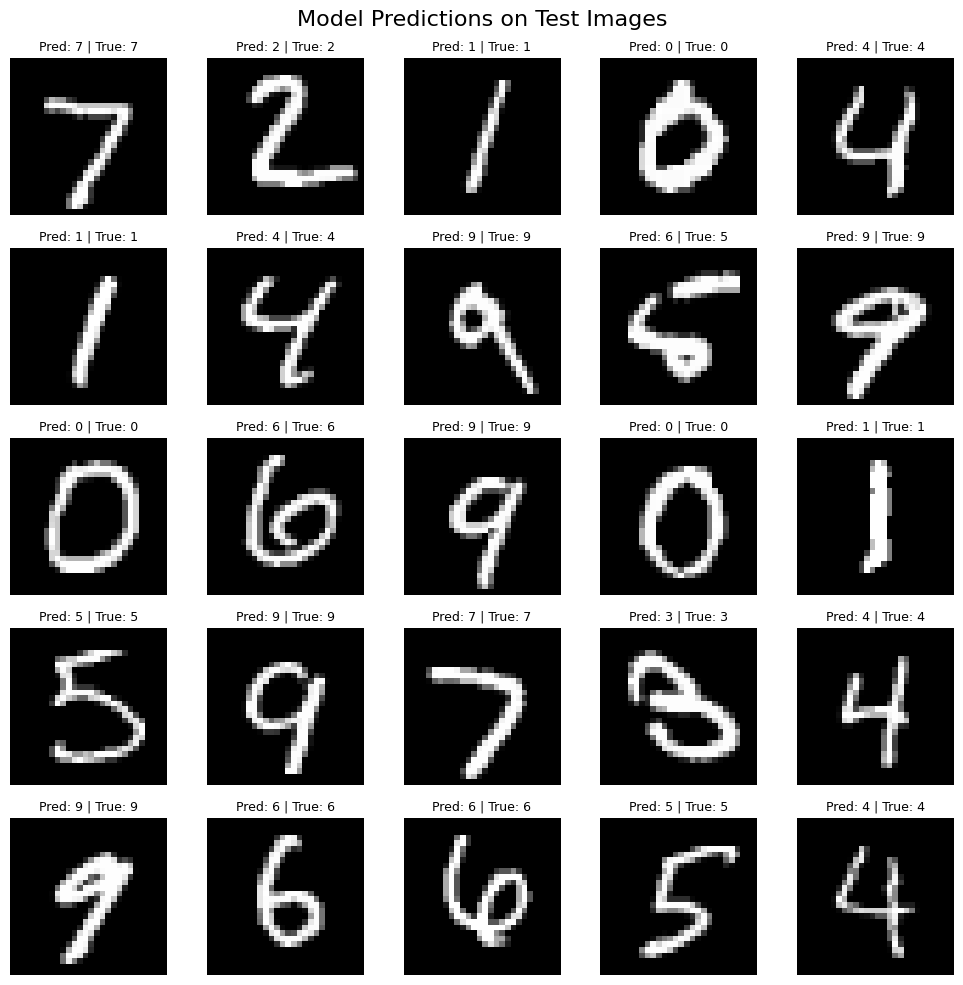

In [66]:
#visualize model predictions on test images
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {predictions_test[i]} | True: {y_test[i]}", fontsize=9)
    plt.axis("off")

plt.suptitle("Model Predictions on Test Images", fontsize=16)
plt.tight_layout()
plt.show()

## Training Curves

The loss and accuracy curves show how the model improves over time.

A healthy training process should show decreasing loss and increasing accuracy.

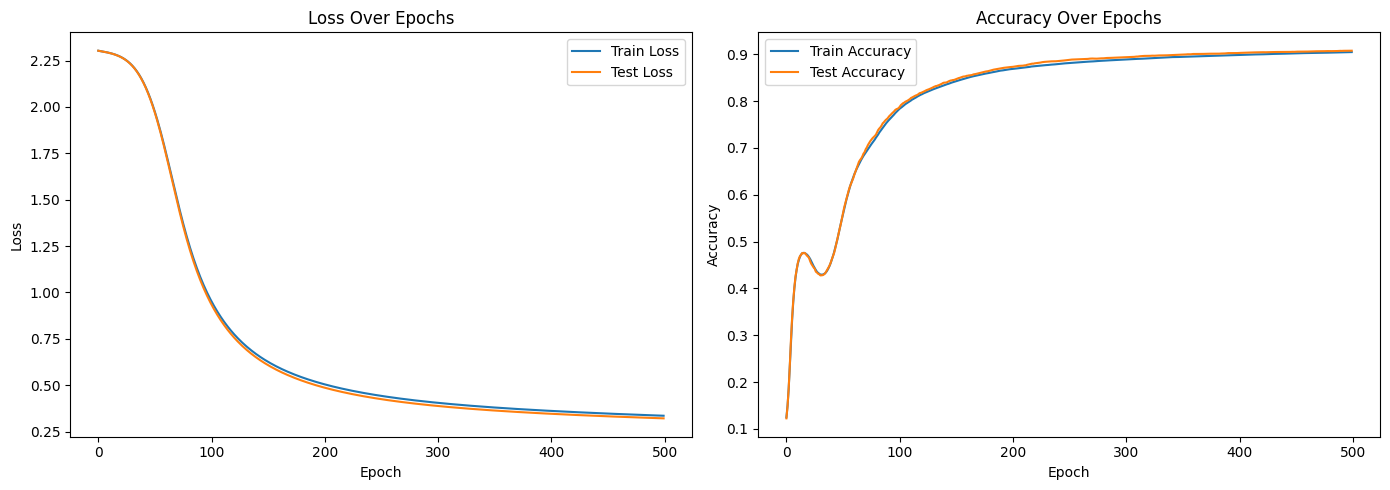

In [67]:
#visualize training and test performance over epochs
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label="Train Loss")
plt.plot(test_loss_list, label="Test Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(test_acc_list, label="Test Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Final Results

After 500 epochs of training, the neural network successfully learned to classify handwritten digits from the MNIST dataset with over 90% test accuracy.

Key takeaways from this project:

- Built a neural network entirely from scratch using NumPy
- Implemented forward propagation, backpropagation, and gradient descent manually
- Understood the mathematical relationship between softmax and cross-entropy loss
- Visualized training behavior through loss and accuracy curves
- Achieved strong performance without using deep learning frameworks

I love Neural Networks.


## Final Model Performance

After training, I evaluated the final loss and accuracy on both the training and test sets.

In [68]:
final_train_loss = train_loss_list[-1]
final_test_loss = test_loss_list[-1]
final_train_accuracy = train_acc_list[-1]
final_test_accuracy = test_acc_list[-1]

print("Final Model Performance")
print("-----------------------")
print(f"Train Loss: {final_train_loss:.4f}")
print(f"Test Loss: {final_test_loss:.4f}")
print(f"Train Accuracy: {final_train_accuracy:.4f}")
print(f"Test Accuracy: {final_test_accuracy:.4f}")

Final Model Performance
-----------------------
Train Loss: 0.3357
Test Loss: 0.3216
Train Accuracy: 0.9048
Test Accuracy: 0.9077


## Misclassified Examples

To better understand where the model struggles, I visualized examples where the predicted label does not match the true label.

Even I couldn't guess the first number...

In [ ]:
#find misclassified test examples
misclassified_indices = np.where(predictions_test != y_test)[0]
print(f"Number of misclassified test images: {len(misclassified_indices)}")
print(f"Number of correctly classified test images: {len(y_test) - len(misclassified_indices)}")

Number of misclassified test images: 923
Number of correctly classified test images: 9077


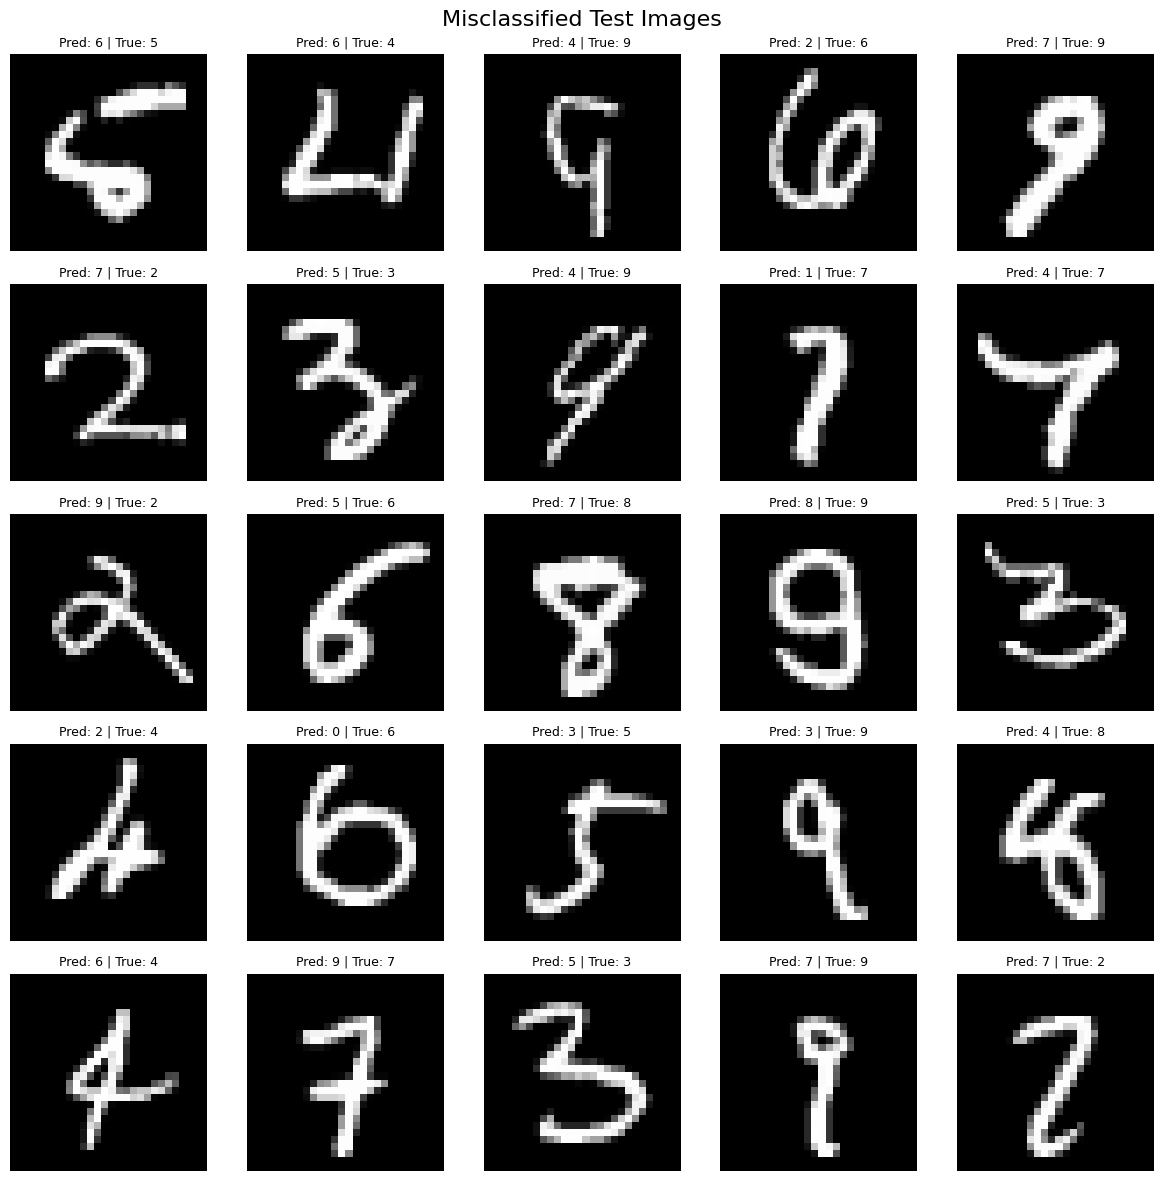

In [70]:
#visualize the first 25 misclassified examples
plt.figure(figsize=(12, 12))

for i, index in enumerate(misclassified_indices[:25]):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_test[index].reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {predictions_test[index]} | True: {y_test[index]}", fontsize=9
    )
    plt.axis("off")

plt.suptitle("Misclassified Test Images", fontsize=16)
plt.tight_layout()
plt.show()

## Confusion Matrix

A confusion matrix shows how often each digit is classified as every other digit.

This helps identify which classes the model confuses most frequently.

In [71]:
#build confusion matrix manually
confusion_matrix = np.zeros((10, 10), dtype=int)

for true_label, predicted_label in zip(y_test, predictions_test):
    confusion_matrix[true_label, predicted_label] += 1

confusion_matrix

array([[ 957,    0,    5,    2,    0,    5,    8,    1,    2,    0],
       [   0, 1107,    1,    3,    0,    2,    4,    1,   17,    0],
       [  12,   10,  905,   14,   15,    1,   17,   13,   39,    6],
       [   3,    0,   21,  904,    0,   36,    1,   17,   20,    8],
       [   1,    1,    5,    1,  911,    1,   12,    2,    7,   41],
       [  14,    3,    5,   50,   12,  742,   17,    9,   34,    6],
       [  17,    3,    7,    0,   19,   16,  892,    1,    3,    0],
       [   6,   14,   28,    3,    7,    0,    0,  933,    3,   34],
       [   7,    8,    9,   28,   12,   30,   16,   10,  840,   14],
       [  11,    6,    3,   10,   45,   13,    1,   27,    7,  886]])

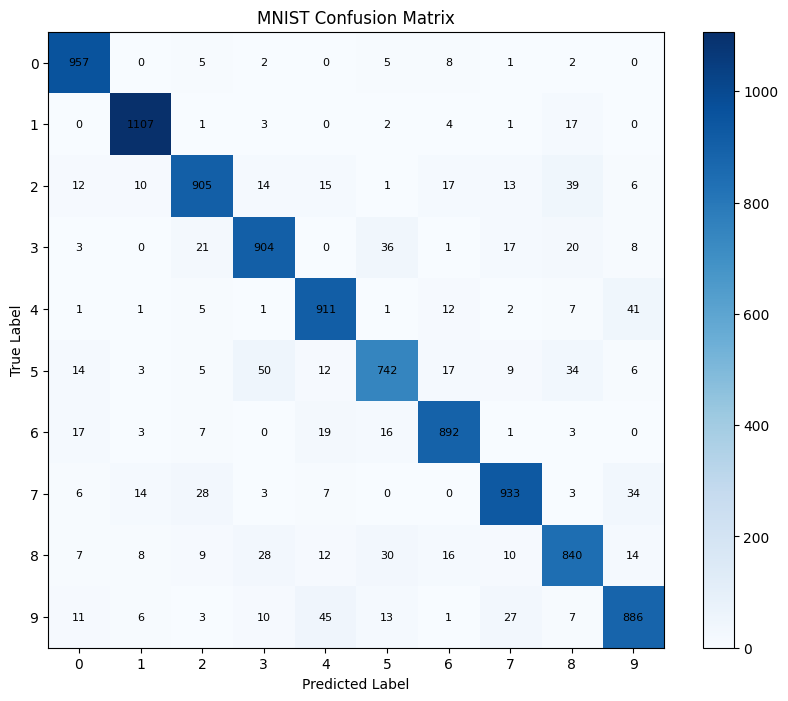

In [72]:
#visualize confusion matrix
plt.figure(figsize=(10, 8))

plt.imshow(confusion_matrix, cmap="Blues")
plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MNIST Confusion Matrix")

# Add numbers inside cells
for i in range(10):
    for j in range(10):
        plt.text(j, i, confusion_matrix[i, j], ha="center", va="center", color="black", fontsize=8)

plt.show()

## Final Results

After 500 epochs of training, the neural network successfully learned to classify handwritten digits from the MNIST dataset with strong performance on unseen test data.

The final model achieved over 90% test accuracy while being implemented entirely from scratch using only NumPy.

### What This Project Demonstrated

- Manual implementation of forward propagation
- ReLU and softmax activation functions
- Cross-entropy loss
- Backpropagation using the chain rule
- Gradient descent optimization
- Data preprocessing and normalization
- Performance evaluation using accuracy curves and a confusion matrix
- Error analysis through misclassified examples

### Key Takeaways

One of the most valuable parts of this project was understanding how the mathematics behind neural networks.

Building the network manually was really fun.
